# Student vs Digital Distraction Model
### Import Library and Models

In [19]:
#import math library for training 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#IMPORT MODELS FOR TRAINING 
#import Naive Bayes model 
from sklearn.naive_bayes import GaussianNB
#import logistic regression model 
from sklearn.linear_model import LogisticRegression
#import decision tree model
from sklearn.tree import DecisionTreeClassifier, plot_tree

#other import that will help cleaning the data
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

### Import Dataset

In [20]:
df = pd.read_csv('student_digital_life.csv')
#NOTICE: To rerun the program again, you HAVE TO import the original dataset to the project folder. Because all the function that is used to update the column will mess up with the original dataset

### Display Dataset information 

In [21]:
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())


Dataset shape: (15000, 18)

First few rows:
   student_id  age  gender  study_hours_per_day  smartphone_usage_hours  \
0           1   21  Female                 3.01                    0.26   
1           2   23  Female                 5.84                    8.02   
2           3   20  Female                 7.80                   10.13   
3           4   20  Female                 0.00                    1.15   
4           5   24    Male                 7.23                    1.39   

   social_media_hours  gaming_hours  streaming_hours  sleep_hours  \
0                1.77          0.26             1.71         5.32   
1                3.30          0.96             0.00         5.99   
2                0.00          2.23             2.54         6.36   
3                1.32          4.19             0.27         7.86   
4                2.21          4.67             2.75         7.88   

   exercise_hours  class_attendance_percent  assignment_completion_percent  \
0           

### WIP: Cleaning data and ready for training 

In [22]:
# Create total distraction time feature
distraction_columns = ['social_media_hours', 'gaming_hours', 'streaming_hours', 'smartphone_usage_hours']
df['total_distraction_time'] = df[distraction_columns].sum(axis=1)

print("\nTotal distraction time statistics:")
print(df['total_distraction_time'].describe())

# Convert continuous exam score to classification (Pass/Fail) Pass >= 70, Fail < 70
df['exam_performance'] = (df['final_exam_score'] >= 70).astype(int)  # 1 = Pass, 0 = Fail

print("\nExam Performance Distribution (Pass/Fail):")
print(df['exam_performance'].value_counts())
print(f"Pass rate: {df['exam_performance'].mean()*100:.2f}%")

# Prepare features and target, and select features for the model
feature_columns = [
    'age', 
    'study_hours_per_day',
    'total_distraction_time',  # Your new feature
    'sleep_hours',
    'exercise_hours',
    'class_attendance_percent',
    'assignment_completion_percent',
    'caffeine_intake_cups',
    'motivation_level'
]

# Handle categorical variables
le_gender = LabelEncoder()
le_mental_health = LabelEncoder()
le_internet = LabelEncoder()

df['gender_encoded'] = le_gender.fit_transform(df['gender'])
df['mental_health_encoded'] = le_mental_health.fit_transform(df['mental_health_status'])
df['internet_encoded'] = le_internet.fit_transform(df['internet_quality'])

# Add encoded categorical features
feature_columns.extend(['gender_encoded', 'mental_health_encoded', 'internet_encoded'])

X = df[feature_columns]
y = df['exam_performance']

# Check for missing values
print("\nMissing values:")
print(X.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Total distraction time statistics:
count    15000.000000
mean        13.090861
std          3.579100
min          1.060000
25%         10.640000
50%         13.030000
75%         15.520000
max         30.830000
Name: total_distraction_time, dtype: float64

Exam Performance Distribution (Pass/Fail):
exam_performance
1    10985
0     4015
Name: count, dtype: int64
Pass rate: 73.23%

Missing values:
age                              0
study_hours_per_day              0
total_distraction_time           0
sleep_hours                      0
exercise_hours                   0
class_attendance_percent         0
assignment_completion_percent    0
caffeine_intake_cups             0
motivation_level                 0
gender_encoded                   0
mental_health_encoded            0
internet_encoded                 0
dtype: int64

Training set size: 12000
Test set size: 3000


## Naive Bayes Layer

### Goal
As the first layer of the Machine, Naive Bayes will make simple prediction based on one main variable: Total Distraction time

### Procedure: 
1) The machine will be trained with these data: time spend online, and final exam score (which will determine the predicted label)
2) After the training, the input for a prediction will be the time spend online, the machine will return the prediction if the final score will be aboved average or below average


In [23]:
print("\n" + "="*60)
print("GAUSSIAN NAIVE BAYES - MODEL PERFORMANCE")
print("="*60)

model = GaussianNB()
model.fit(X_train, y_train)

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Get prediction probabilities
y_train_proba = model.predict_proba(X_train)
y_test_proba = model.predict_proba(X_test)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"\nTraining Metrics:")
print(f"  Accuracy:  {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1-Score:  {train_f1:.4f}")

print(f"\nTest Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

# Confusion matrix
print("\n" + "="*60)
print("CONFUSION MATRIX (Test Set)")
print("="*60)
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n           Predicted Fail  Predicted Pass")
print(f"Actual Fail      {cm[0,0]:<14} {cm[0,1]:<14}")
print(f"Actual Pass      {cm[1,0]:<14} {cm[1,1]:<14}")

# Feature statistics from model
print("\n" + "="*60)
print("FEATURE STATISTICS FROM MODEL")
print("="*60)
print("\nClass 0 (Fail) - Mean values:")
for i, feature in enumerate(feature_columns):
    print(f"  {feature}: mean={model.theta_[0, i]:.4f}, variance={model.var_[0, i]:.4f}")

print("\nClass 1 (Pass) - Mean values:")
for i, feature in enumerate(feature_columns):
    print(f"  {feature}: mean={model.theta_[1, i]:.4f}, variance={model.var_[1, i]:.4f}")

# Show which features are more predictive (larger difference in means between classes)
print("\n" + "="*60)
print("FEATURE IMPORTANCE (Mean Difference between Classes)")
print("="*60)
mean_diff = np.abs(model.theta_[1] - model.theta_[0])
feature_importance = sorted(zip(feature_columns, mean_diff), key=lambda x: x[1], reverse=True)
for feature, importance in feature_importance:
    print(f"  {feature}: {importance:.4f}")

# Example predictions with total_distraction_time
print("\n" + "="*60)
print("EXAMPLE PREDICTIONS")
print("="*60)
for idx in range(min(3, len(X_test))):
    example = X_test.iloc[idx].to_frame().T
    example_pred = model.predict(example)[0]
    example_proba = model.predict_proba(example)[0]
    example_actual = y_test.iloc[idx]
    
    print(f"\nExample {idx + 1}:")
    print(f"  Total Distraction Time: {example['total_distraction_time'].values[0]:.2f} hours")
    print(f"  Study Hours per Day: {example['study_hours_per_day'].values[0]:.2f}")
    print(f"  Class Attendance: {example['class_attendance_percent'].values[0]:.2f}%")
    print(f"  Assignment Completion: {example['assignment_completion_percent'].values[0]:.2f}%")
    print(f"  Predicted: {'PASS' if example_pred == 1 else 'FAIL'} (confidence: {max(example_proba):.4f})")
    print(f"  Actual: {'PASS' if example_actual == 1 else 'FAIL'}")
    print(f"  Correct: {'✓' if example_pred == example_actual else '✗'}")


GAUSSIAN NAIVE BAYES - MODEL PERFORMANCE

Training Metrics:
  Accuracy:  0.8478
  Precision: 0.8594
  Recall:    0.9471
  F1-Score:  0.9011

Test Metrics:
  Accuracy:  0.8540
  Precision: 0.8647
  Recall:    0.9496
  F1-Score:  0.9052

CONFUSION MATRIX (Test Set)

           Predicted Fail  Predicted Pass
Actual Fail      472            327           
Actual Pass      111            2090          

FEATURE STATISTICS FROM MODEL

Class 0 (Fail) - Mean values:
  age: mean=21.1076, variance=6.7303
  study_hours_per_day: mean=2.8110, variance=2.4662
  total_distraction_time: mean=13.7519, variance=12.0748
  sleep_hours: mean=6.8857, variance=2.6509
  exercise_hours: mean=1.1974, variance=0.6613
  class_attendance_percent: mean=83.0980, variance=91.8042
  assignment_completion_percent: mean=75.8600, variance=202.4534
  caffeine_intake_cups: mean=1.5062, variance=1.5080
  motivation_level: mean=5.6138, variance=3.8392
  gender_encoded: mean=0.5155, variance=0.2498
  mental_health_encoded: m

# LogisticRegression and DecisionTree Layer

## Procedure for this layer:
    The procedure for this layer is first prepare all data needed for these layer because, different from Naive Bayes, Logistic Regression and Decision Tree will have more elements that affect the training. With that in mind, some variable that can affect the study can be "gender", "mental_health_status", etc

    After preparing all other data, train/test split will be conduct and the model will be train


## Preparing data for Logistic Regression and Decision Tree


In [24]:
df["performance"] = (df["final_exam_score"] >= 70).astype(int)

df_model = df.drop(columns=[
    "student_id", "final_exam_score",
    "smartphone_usage_hours", "social_media_hours",
    "gaming_hours", "streaming_hours",
    "exam_performance"
])

df_model["gender"] = df_model["gender"].map({"Female": 0, "Male": 1})
df_model["mental_health_status"] = df_model["mental_health_status"].map({"Poor": 0, "Average": 1, "Good": 2})
# FIX: encode internet_quality (was missing)
df_model["internet_quality"] = df_model["internet_quality"].map({"Poor": 0, "Average": 1, "Good": 2})
# FIX: correct key is 'HighSchool' not 'High School'
df_model["parent_education_level"] = df_model["parent_education_level"].map(
    {"HighSchool": 0, "Bachelors": 1, "Masters": 2, "PhD": 3})

X = df_model.drop(columns=["performance"])
y = df_model["performance"]

print(f"\n\nPass: {(y==1).mean():.1%}, Fail: {(y==0).mean():.1%}")
print(f"Features: {list(X.columns)}")

# ============================================================
# Train/test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")




Pass: 73.2%, Fail: 26.8%
Features: ['age', 'gender', 'study_hours_per_day', 'sleep_hours', 'exercise_hours', 'class_attendance_percent', 'assignment_completion_percent', 'caffeine_intake_cups', 'mental_health_status', 'parent_education_level', 'internet_quality', 'motivation_level', 'total_distraction_time', 'gender_encoded', 'mental_health_encoded', 'internet_encoded']
Train: 12000, Test: 3000


## Logistic Regression

In [25]:
print("\n" + "="*60)
print("LOGISTIC REGRESSION")
print("="*60)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
lr_pred = logreg.predict(X_test_scaled)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print(f"Accuracy:  {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall:    {lr_rec:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(logreg, X_train_scaled, y_train, cv=cv, scoring="f1")
print(f"5-fold CV F1: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=["Fail","Pass"], digits=4))

lr_coefs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)
print("\nCoefficients:")
print(lr_coefs)


LOGISTIC REGRESSION
Accuracy:  0.8433
Precision: 0.8698
Recall:    0.9244
F1-Score:  0.8963
5-fold CV F1: 0.9001 (+/- 0.0044)

Confusion Matrix:
[[ 499  304]
 [ 166 2031]]

Classification Report:
              precision    recall  f1-score   support

        Fail     0.7504    0.6214    0.6798       803
        Pass     0.8698    0.9244    0.8963      2197

    accuracy                         0.8433      3000
   macro avg     0.8101    0.7729    0.7881      3000
weighted avg     0.8378    0.8433    0.8384      3000


Coefficients:
                          feature  coefficient
2             study_hours_per_day     2.189325
6   assignment_completion_percent     0.618254
8            mental_health_status     0.604275
11               motivation_level     0.487485
12         total_distraction_time    -0.487156
5        class_attendance_percent     0.448720
9          parent_education_level     0.251689
3                     sleep_hours     0.215742
14          mental_health_encoded    -

## Decision Tree


DECISION TREE
Accuracy:  0.8250
Precision: 0.8536
Recall:    0.9185
F1-Score:  0.8849
5-fold CV F1: 0.8890 (+/- 0.0040)

Confusion Matrix:
[[ 457  346]
 [ 179 2018]]

Classification Report:
              precision    recall  f1-score   support

        Fail     0.7186    0.5691    0.6352       803
        Pass     0.8536    0.9185    0.8849      2197

    accuracy                         0.8250      3000
   macro avg     0.7861    0.7438    0.7600      3000
weighted avg     0.8175    0.8250    0.8180      3000


Feature Importances:
                          feature  importance
2             study_hours_per_day    0.733631
14          mental_health_encoded    0.063778
6   assignment_completion_percent    0.058427
3                     sleep_hours    0.038711
12         total_distraction_time    0.037395
11               motivation_level    0.031554
5        class_attendance_percent    0.024489
8            mental_health_status    0.010400
4                  exercise_hours    0.001042


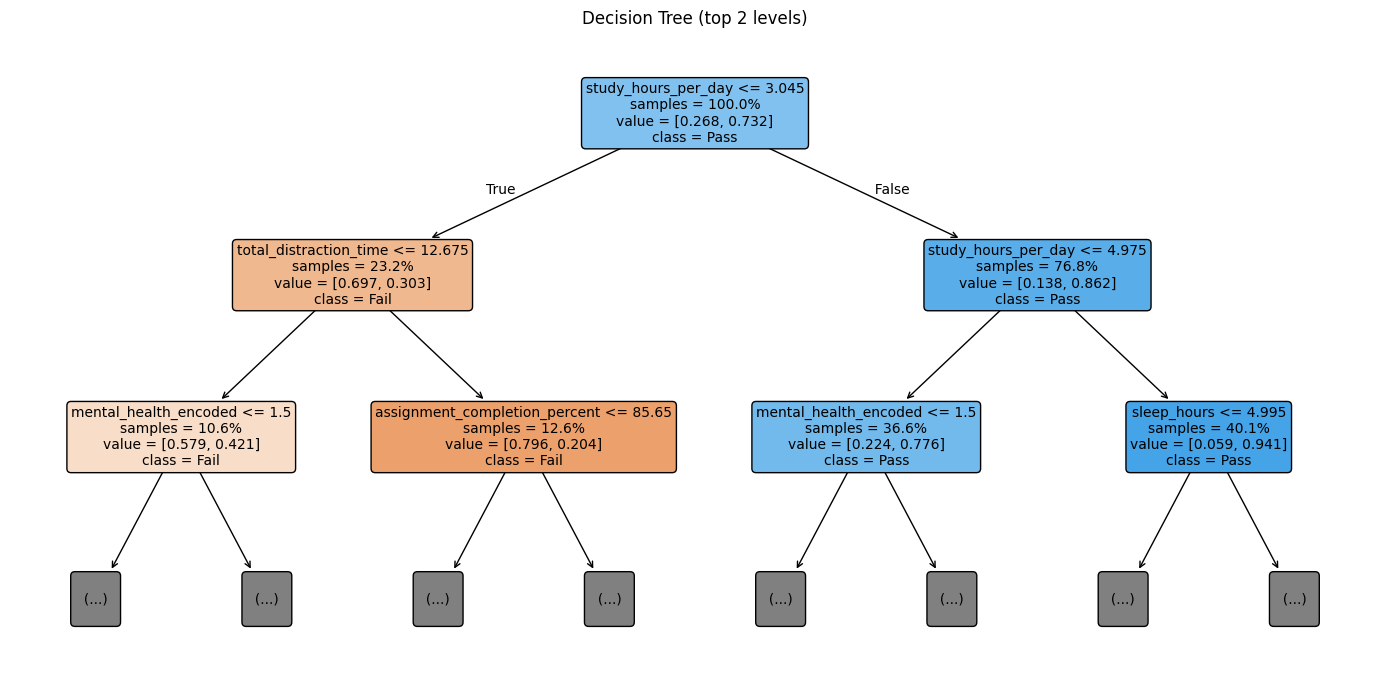

In [26]:
print("\n" + "="*60)
print("DECISION TREE")
print("="*60)

dtree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dtree.fit(X_train, y_train)
dt_pred = dtree.predict(X_test)

dt_acc  = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec  = recall_score(y_test, dt_pred)
dt_f1   = f1_score(y_test, dt_pred)

print(f"Accuracy:  {dt_acc:.4f}")
print(f"Precision: {dt_prec:.4f}")
print(f"Recall:    {dt_rec:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")

dt_cv = cross_val_score(dtree, X_train, y_train, cv=cv, scoring="f1")
print(f"5-fold CV F1: {dt_cv.mean():.4f} (+/- {dt_cv.std():.4f})")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=["Fail","Pass"], digits=4))

dt_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": dtree.feature_importances_
}).sort_values("importance", ascending=False)
print("\nFeature Importances:")
print(dt_imp)

# Visualize tree (top 2 levels)
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(dtree, feature_names=X.columns, class_names=["Fail","Pass"],
          filled=True, max_depth=2, fontsize=10, rounded=True,
          impurity=False, proportion=True, ax=ax)
plt.title("Decision Tree (top 2 levels)")
plt.tight_layout()
plt.show()
